# Data Encoding in Quantum Machine Learning

## Mapping Classical Data into Quantum States with Qiskit 2.x
---

### What This Notebook Covers

Data encoding (also called **feature mapping**) is the critical first step in any quantum machine learning pipeline. Classical data must be embedded into quantum states before a quantum computer can process it. The choice of encoding profoundly affects model expressivity, circuit depth, and whether any quantum advantage is achievable.

**Topics:**

1. **Introduction & Notation** — Dataset conventions, normalization vs. quantum normalization
2. **Basis Encoding** — Binary strings → computational basis states
3. **Amplitude Encoding** — Data vector → state amplitudes (logarithmic qubit scaling)
4. **Angle Encoding** — Features → rotation angles ($R_Y$ gates)
5. **Phase Encoding** — Features → relative phases ($P$ gates)
6. **Dense Angle Encoding** — Two features per qubit ($R_Y + R_Z$)
7. **Built-in Feature Maps** — `ZFeatureMap`, `ZZFeatureMap`, `PauliFeatureMap`, `EfficientSU2`
8. **Comparison** — Qubit count, circuit depth, expressibility summary

---

## 1. Setup and Imports

In [33]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit.circuit.library import (
    z_feature_map,
    zz_feature_map,
    pauli_feature_map,
    efficient_su2,
)

np.set_printoptions(precision=4, suppress=True)

### Running Example Data

We use a small synthetic vector throughout so the math stays transparent:

$$\vec{x} = (4,\; 8,\; 5,\; 9)$$

In [34]:
x = np.array([4, 8, 5, 9], dtype=float)
print(f"Data vector:  x = {x}")
print(f"Dimension N = {len(x)}")
print(f"L2 norm     = {np.linalg.norm(x):.4f}")

Data vector:  x = [4. 8. 5. 9.]
Dimension N = 4
L2 norm     = 13.6382


---

## 2. Introduction & Notation

### Dataset Convention

A dataset $\mathcal{X} = \{\vec{x}^{(j)} \mid j \in [M]\}$ contains $M$ vectors, each of dimension $N$.

A **feature map** $\Phi$ (classical) or **unitary encoding** $U(\vec{x})$ (quantum) transforms classical data into a representation suitable for the learning algorithm:

$$\vec{x} \;\xrightarrow{\;U(\vec{x})\;}\; \vert\psi_x\rangle = U(\vec{x})\vert 0\rangle^{\otimes n}$$

### Normalization: Classical vs. Quantum

| | Classical (min-max) | Quantum |
|---|---|---|
| **Goal** | Rescale features to $[0,1]$ | Ensure $\lVert\psi\rVert_2 = 1$ |
| **Formula** | $x'_k = \frac{x_k - \min}{\max - \min}$ | $\vert\psi\rangle = \frac{1}{\alpha}\sum_i x_i \vert i\rangle$, where $\alpha = \sqrt{\sum \vert x_i\vert^2}$ |
| **Mandatory?** | Helpful | **Required** by quantum mechanics |

Classical normalization rescales feature ranges; quantum normalization ensures the state vector has unit 2-norm — these are distinct operations.

---

## 3. Basis Encoding

Converts a classical integer into a computational basis state. Each bit maps to a qubit using Qiskit's **little-endian** convention — qubit $k$ holds bit $k$ (the $2^k$ place).

$$x \;\rightarrow\; \vert b_{P-1} \cdots b_1\, b_0\rangle, \qquad \text{where } x = \sum_{k=0}^{P-1} b_k\, 2^k$$

**Example:** $x = 5 = 0101_2 \;\rightarrow\; \vert 0101\rangle$ on 4 qubits (X gates on $q_0$ and $q_2$).

| Property | Value |
|---|---|
| Qubits needed | $P$ (one per bit) |
| Circuit depth | 1 (parallel X gates) |
| State type | Computational basis state |

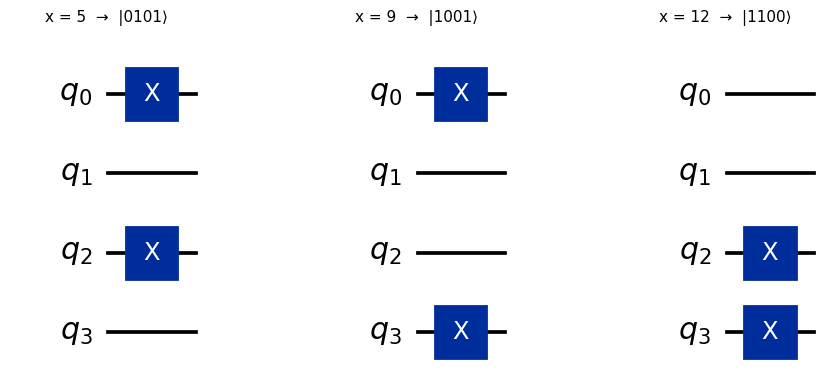

In [35]:
def basis_encode(integer_val, num_bits=4):
    bits = format(integer_val, f"0{num_bits}b")
    qc = QuantumCircuit(num_bits)
    for k in range(num_bits):
        if (integer_val >> k) & 1:
            qc.x(k)
    return qc, bits


values_to_encode = [5, 9, 12]
fig, axes = plt.subplots(1, len(values_to_encode), figsize=(10, 4))

for ax, val in zip(axes, values_to_encode):
    qc, bits = basis_encode(val)
    qc.draw("mpl", ax=ax)
    ax.set_title(f"x = {val}  →  |{bits}⟩", fontsize=11)

plt.tight_layout()
plt.show()

In [36]:
qc_basis, bits = basis_encode(5)
sv = Statevector.from_instruction(qc_basis)
print(f"Basis encoding of 5 = |{bits}⟩")
print(f"Statevector (non-zero entry): {sv}")
sv.draw("latex")

Basis encoding of 5 = |0101⟩
Statevector (non-zero entry): Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j],
            dims=(2, 2, 2, 2))


<IPython.core.display.Latex object>

---

## 4. Amplitude Encoding

Encodes a normalized $N$-dimensional data vector as the **amplitudes** of an $n$-qubit quantum state.

$$|\psi_x\rangle = \frac{1}{\alpha}\sum_{i=1}^{N} x_i\,|i\rangle, \qquad \alpha = \sqrt{\sum_{i=1}^{N}|x_i|^2}$$

Requires $n \geq \lceil\log_2 N\rceil$ qubits — **exponentially compact**.

| Property | Value |
|---|---|
| Qubits needed | $\lceil \log_2 N \rceil$ |
| Circuit depth | $O(2^n)$ in general |
| State type | Arbitrary superposition |

**Example:** $\vec{x} = (4, 8, 5, 9)$, $\alpha = \sqrt{16+64+25+81} = \sqrt{186}$

$$|\psi_x\rangle = \frac{1}{\sqrt{186}}\big(4|00\rangle + 8|01\rangle + 5|10\rangle + 9|11\rangle\big)$$

In [37]:
alpha = np.linalg.norm(x)
x_normalized = x / alpha
n_qubits = int(np.ceil(np.log2(len(x))))

print(f"x           = {x}")
print(f"α           = √{int(alpha**2)} = {alpha:.4f}")
print(f"Normalized  = {x_normalized}")
print(f"Qubits      = ⌈log₂({len(x)})⌉ = {n_qubits}")
print(f"‖ψ‖²       = {np.sum(x_normalized**2):.6f} (must be 1)")

x           = [4. 8. 5. 9.]
α           = √185 = 13.6382
Normalized  = [0.29329423 0.58658846 0.36661779 0.65991202]
Qubits      = ⌈log₂(4)⌉ = 2
‖ψ‖²       = 1.000000 (must be 1)


Statevector amplitudes: [0.29329423+0.j 0.58658846+0.j 0.36661779+0.j 0.65991202+0.j]


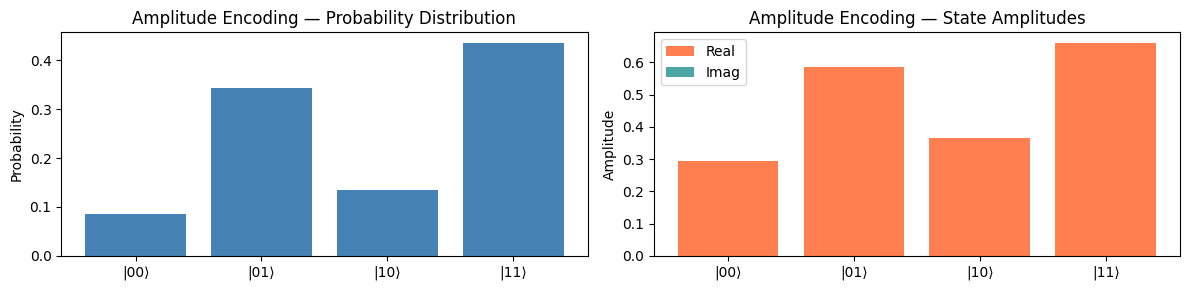

In [38]:
qc_amp = QuantumCircuit(n_qubits)
qc_amp.initialize(x_normalized)

sv_amp = Statevector.from_instruction(qc_amp)
print("Statevector amplitudes:", sv_amp.data)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

labels = [f"|{format(i, f'0{n_qubits}b')}⟩" for i in range(2**n_qubits)]
axes[0].bar(labels, np.abs(sv_amp.data) ** 2, color="steelblue")
axes[0].set_ylabel("Probability")
axes[0].set_title("Amplitude Encoding — Probability Distribution")

axes[1].bar(labels, sv_amp.data.real, color="coral", label="Real")
axes[1].bar(labels, sv_amp.data.imag, color="teal", alpha=0.7, label="Imag")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Amplitude Encoding — State Amplitudes")
axes[1].legend()

plt.tight_layout()
plt.show()

Gate count after decomposition: OrderedDict([('u', 3), ('reset', 2), ('cx', 1)])
Circuit depth: 4


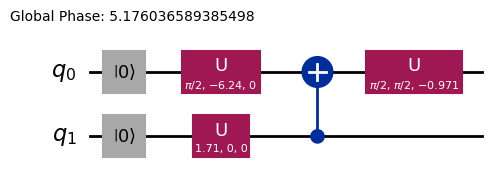

In [39]:
qc_amp_decomposed = qc_amp.decompose(reps=5)
print(f"Gate count after decomposition: {qc_amp_decomposed.count_ops()}")
print(f"Circuit depth: {qc_amp_decomposed.depth()}")
qc_amp_decomposed.draw("mpl", fold=-1)

> **Key takeaway:** Amplitude encoding is qubit-efficient ($\log_2 N$ qubits) but the state-preparation circuit can be deep — $O(2^n)$ gates in general. This is a fundamental trade-off.

---

## 5. Angle Encoding

Each feature $x_k$ is mapped to a **rotation angle** on a dedicated qubit using $R_Y$ or $R_X$ gates:

$$R_Y(x_k)\,\vert 0\rangle = \cos\!\left(\frac{x_k}{2}\right)\vert 0\rangle + \sin\!\left(\frac{x_k}{2}\right)\vert 1\rangle$$

$$R_X(x_k)\,\vert 0\rangle = \cos\!\left(\frac{x_k}{2}\right)\vert 0\rangle - i\sin\!\left(\frac{x_k}{2}\right)\vert 1\rangle$$

Both produce **identical measurement probabilities** $\big(\cos^2\!\frac{x_k}{2},\;\sin^2\!\frac{x_k}{2}\big)$. The only difference is the phase of the $\vert 1\rangle$ amplitude — $R_Y$ gives real amplitudes, $R_X$ introduces a factor of $-i$. In practice $R_Y$ is the more common choice.

For $N$ features, the full state is a **product state** (no entanglement):

$$\vert\vec{x}\rangle = \bigotimes_{k=1}^{N} R_Y(x_k)\,\vert 0\rangle$$

| Property | Value |
|---|---|
| Qubits needed | $N$ (one per feature) |
| Circuit depth | 1 |
| State type | Product state |
| Rotation gate | $R_Y$ or $R_X$ (same probabilities) |
| Data range | Rescale $x_k \in (0, 2\pi]$ |

Original:  [4. 8. 5. 9.]
Rescaled (0, 2π]: [2.7925268  5.58505361 3.4906585  6.28318531]


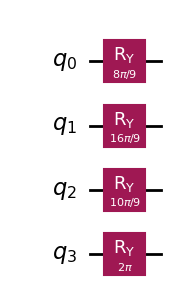

In [40]:
x_angle = x * 2 * np.pi / np.max(x)
print(f"Original:  {x}")
print(f"Rescaled (0, 2π]: {x_angle}")

n = len(x_angle)
qc_angle = QuantumCircuit(n)
for k in range(n):
    qc_angle.ry(x_angle[k], k)

qc_angle.draw("mpl")

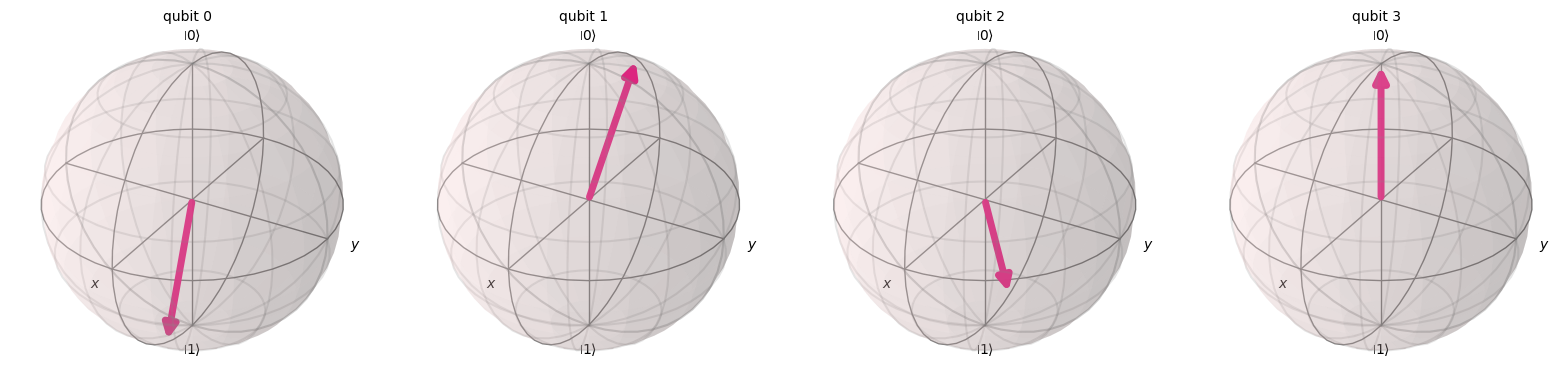

In [41]:
sv_angle = Statevector.from_instruction(qc_angle)
plot_bloch_multivector(sv_angle)

Each qubit sits independently on the Bloch sphere — no correlations between qubits. The $R_Y$ rotation tilts each qubit from $|0\rangle$ toward $|1\rangle$ by an amount proportional to the feature value.

---

## 6. Phase Encoding

Encodes data as **relative phases** using phase gates $P(\phi)$ after a Hadamard layer:

$$|x_k\rangle = P(\phi = x_k)\,|+\rangle = \frac{1}{\sqrt{2}}\big(|0\rangle + e^{i x_k}|1\rangle\big)$$

where $|+\rangle = H|0\rangle$. Multi-qubit state:

$$|\vec{x}\rangle = \frac{1}{\sqrt{2^N}}\bigotimes_{k=1}^{N}\big(|0\rangle + e^{i x_k}|1\rangle\big)$$

| Property | Value |
|---|---|
| Qubits needed | $N$ |
| Circuit depth | 2 (H layer + P layer) |
| State type | Product state |
| Data range | Rescale $x_k \in (0, 2\pi]$ |

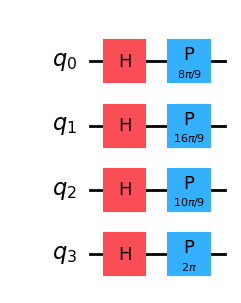

In [42]:
x_phase = x * 2 * np.pi / np.max(x)

qc_phase = QuantumCircuit(len(x_phase))
for k in range(len(x_phase)):
    qc_phase.h(k)
    qc_phase.p(x_phase[k], k)

qc_phase.draw("mpl")

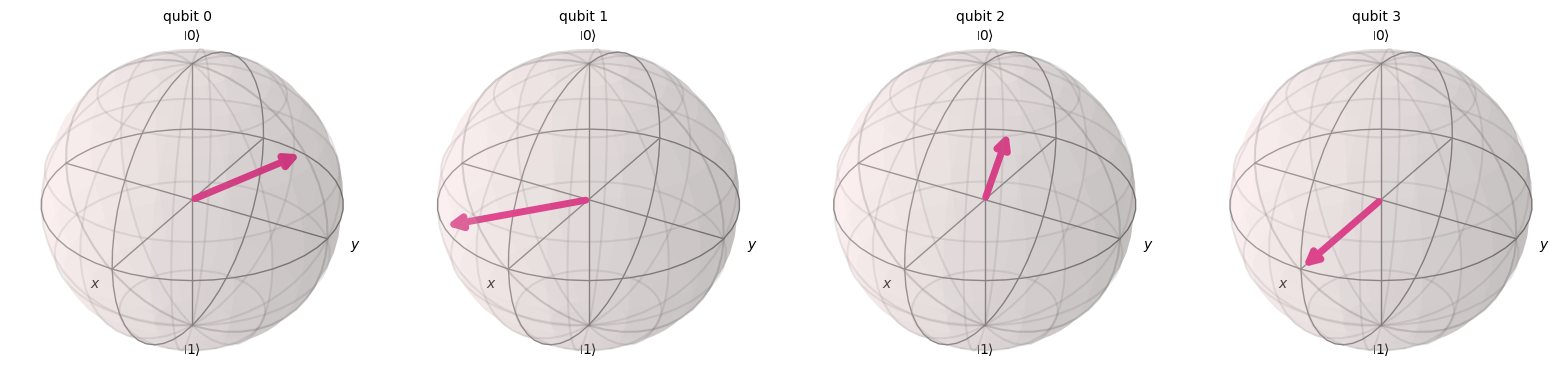

In [43]:
sv_phase = Statevector.from_instruction(qc_phase)
plot_bloch_multivector(sv_phase)

All qubits remain on the equator of the Bloch sphere (equal superposition of $|0\rangle$ and $|1\rangle$) — the data is encoded purely in the **azimuthal angle** (phase), not the polar angle.

---

## 7. Dense Angle Encoding

Combines angle and phase encoding to pack **two features per qubit** using $R_Y$ and $R_Z$:

$$|x_k, x_\ell\rangle = R_Z(x_\ell)\, R_Y(x_k)\,|0\rangle = \cos\!\left(\frac{x_k}{2}\right)|0\rangle + e^{i x_\ell}\sin\!\left(\frac{x_k}{2}\right)|1\rangle$$

$N$ features require only $\lceil N/2 \rceil$ qubits.

| Property | Value |
|---|---|
| Qubits needed | $\lceil N/2 \rceil$ |
| Circuit depth | 2 ($R_Y$ + $R_Z$ per qubit) |
| State type | Product state |
| Data range | Rescale to $(0, 2\pi]$ |

Features: 16  →  Qubits: 8  (2× compression)


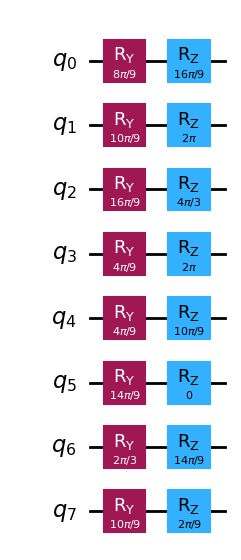

In [44]:
dense_data = np.array([4, 8, 5, 9, 8, 6, 2, 9, 2, 5, 7, 0, 3, 7, 5, 1], dtype=float)
dense_scaled = dense_data * 2 * np.pi / np.max(dense_data)

n_dense = int(np.ceil(len(dense_scaled) / 2))
qc_dense = QuantumCircuit(n_dense)

idx = 0
for q in range(n_dense):
    qc_dense.ry(dense_scaled[idx], q)
    idx += 1
    if idx < len(dense_scaled):
        qc_dense.rz(dense_scaled[idx], q)
        idx += 1

print(f"Features: {len(dense_data)}  →  Qubits: {n_dense}  (2× compression)")
qc_dense.draw("mpl")

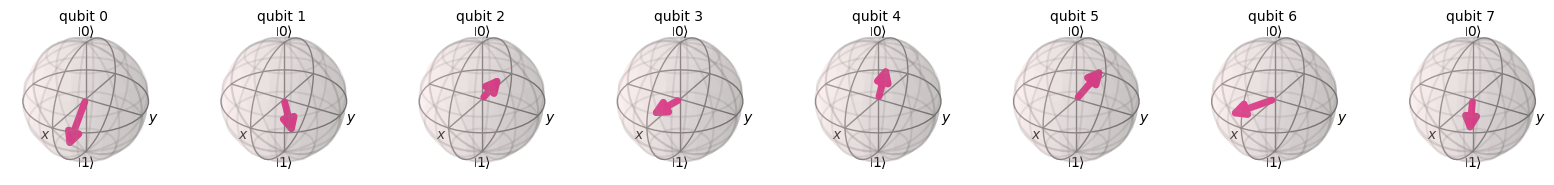

In [45]:
sv_dense = Statevector.from_instruction(qc_dense)
plot_bloch_multivector(sv_dense)

Each qubit now encodes **two** classical features — $R_Y$ controls the polar angle (how much $|0\rangle$ vs. $|1\rangle$) and $R_Z$ controls the azimuthal angle (relative phase). This gives twice the encoding density of angle or phase encoding alone.

---

## 8. Built-in Feature Maps

Qiskit provides parameterized circuits designed specifically for quantum feature mapping. These go beyond product states by incorporating **entanglement**, which is conjectured to be necessary for quantum advantage.

### 8.1 Z Feature Map (ZFM)

Single-qubit rotations with Hadamard and phase gates. For one repetition:

$$\mathcal{U}_{\text{ZFM}} = \left(\bigotimes_{k=1}^{N} P(x_k)\right) H^{\otimes N}$$

With $r$ repetitions:

$$\mathcal{U}_{\text{ZFM}}^{(r)}(\vec{x}) = \prod_{s=1}^{r}\left[\left(\bigotimes_{k=1}^{N} P(x_k)\right) H^{\otimes N}\right]$$

**No entanglement** — produces product states. Classically efficiently simulable.

Parameters: 3, Qubits: 3


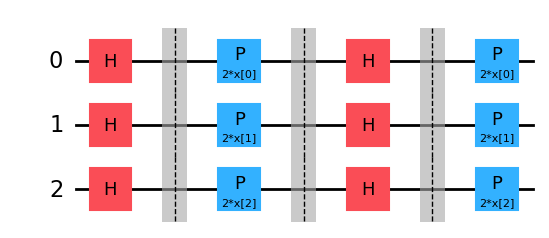

In [46]:
zfm = z_feature_map(feature_dimension=3, reps=2, insert_barriers=True)
print(f"Parameters: {zfm.num_parameters}, Qubits: {zfm.num_qubits}")
zfm.draw("mpl", fold=-1)

Bound with x = [0.8, 1.5, 2.3]


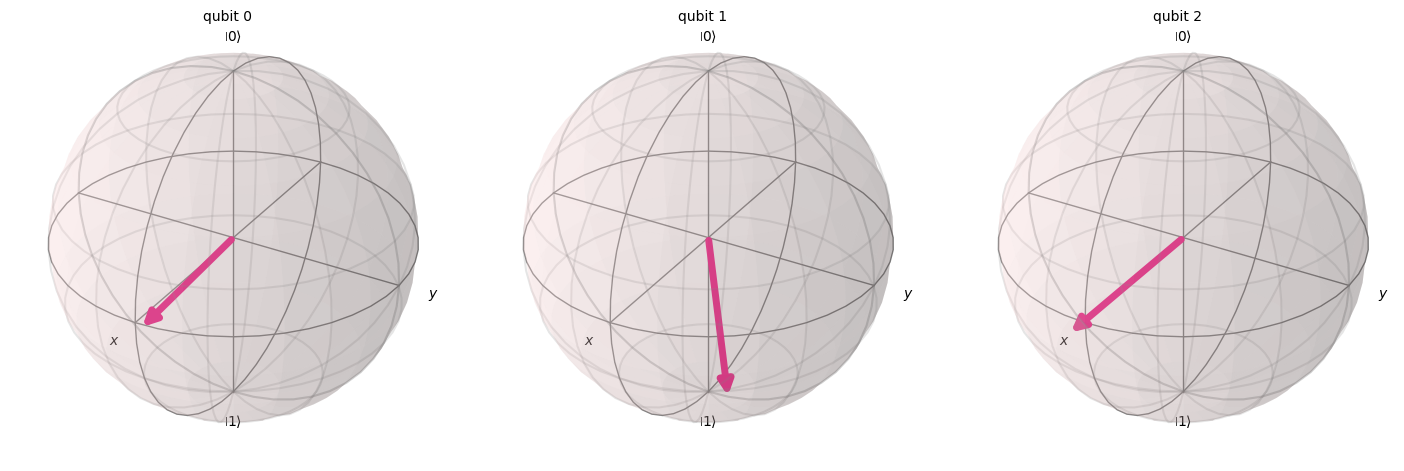

In [47]:
x_zfm = [0.8, 1.5, 2.3]
zfm_bound = zfm.assign_parameters(x_zfm)
sv_zfm = Statevector.from_instruction(zfm_bound)
print(f"Bound with x = {x_zfm}")
plot_bloch_multivector(sv_zfm)

### 8.2 ZZ Feature Map (ZZFM)

Extends ZFM with two-qubit entangling gates $R_{ZZ}(\theta)$:

$$\mathcal{U}_{\text{ZZFM}}(\vec{x}) = U_{ZZ}(\vec{x})\left(\bigotimes_{k=1}^{N} P(x_k)\right) H^{\otimes N}$$

The entangling phase combines features:

$$\theta_{q,p} = \phi(x_q, x_p) = 2(\pi - x_q)(\pi - x_p)$$

This creates **entangled states** and is conjectured to be classically hard to simulate.

**Entanglement schemes:** `linear`, `circular`, `full`

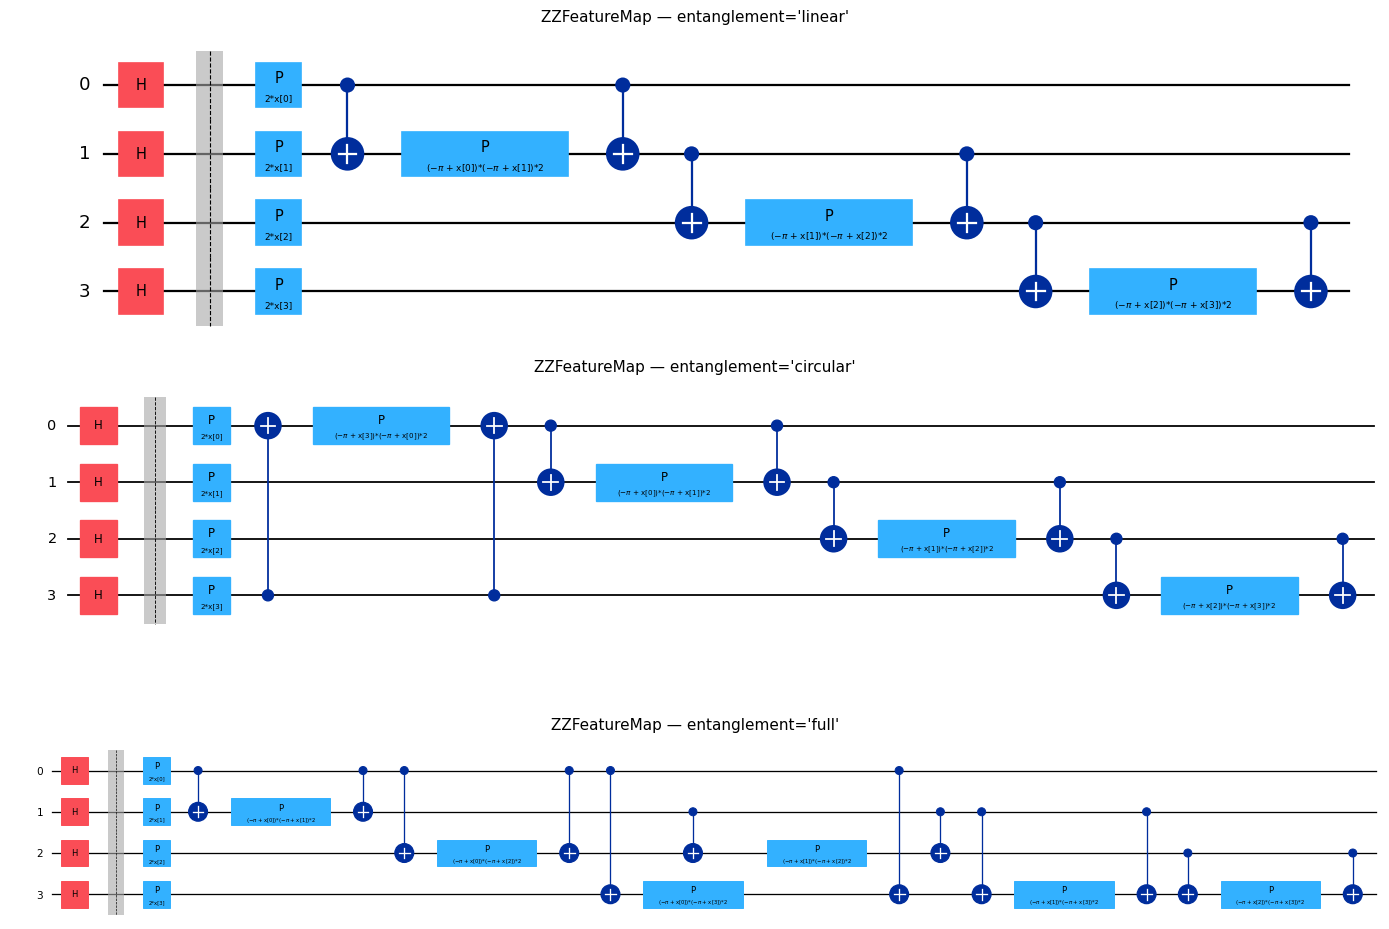

In [48]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, ent in zip(axes, ["linear", "circular", "full"]):
    zzfm = zz_feature_map(feature_dimension=4, entanglement=ent, reps=1, insert_barriers=True)
    zzfm.draw("mpl", ax=ax, fold=-1)
    ax.set_title(f"ZZFeatureMap — entanglement='{ent}'", fontsize=11)

plt.tight_layout()
plt.show()

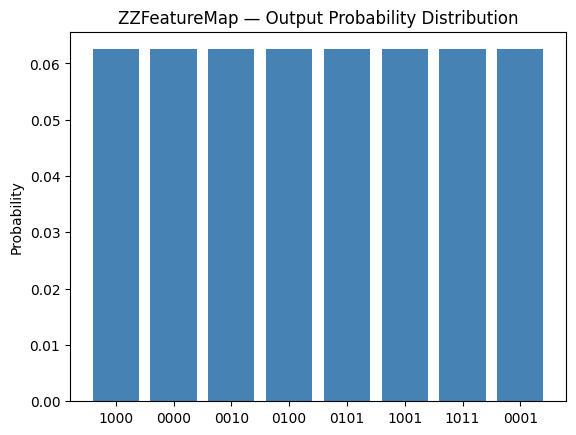

In [49]:
zzfm = zz_feature_map(feature_dimension=4, entanglement="linear", reps=1)
x_zzfm = [0.5, 1.0, 1.5, 2.0]
zzfm_bound = zzfm.assign_parameters(x_zzfm)

sv_zzfm = Statevector.from_instruction(zzfm_bound)
probs = sv_zzfm.probabilities_dict()

top_states = sorted(probs.items(), key=lambda p: p[1], reverse=True)[:8]
labels, vals = zip(*top_states)
plt.bar(labels, vals, color="steelblue")
plt.ylabel("Probability")
plt.title("ZZFeatureMap — Output Probability Distribution")
plt.show()

### 8.3 Pauli Feature Map (PFM)

Generalizes to arbitrary Pauli operators ($X$, $Y$, $Z$) for the entangling layers:

$$U(\vec{x}) = \exp\!\left(i \sum_{S \subseteq [n]} \phi_S(\vec{x})\prod_{i \in S} \sigma_i\right)$$

Feature mapping functions:
- Single-qubit: $\phi_{\{i\}}(\vec{x}) = x_i$
- Multi-qubit: $\phi_S(\vec{x}) = \prod_{j \in S}(\pi - x_j)$

A scaling parameter $\alpha$ (default 2) controls the feature mapping:

$$U(\vec{x}) = \exp\!\left(i\alpha \sum_{S \subseteq [n]} \phi_S(\vec{x})\prod_{i \in S} \sigma_i\right)$$

Parameters: 3, Qubits: 3


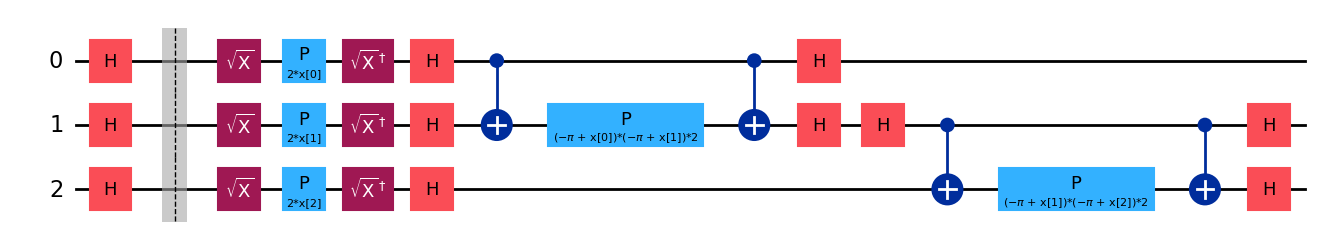

In [50]:
pfm = pauli_feature_map(
    feature_dimension=3,
    entanglement="linear",
    reps=1,
    paulis=["Y", "XX"],
    insert_barriers=True,
)
print(f"Parameters: {pfm.num_parameters}, Qubits: {pfm.num_qubits}")
pfm.draw("mpl", fold=-1)

PFM with paulis=['Z','ZZ'] is equivalent to ZZFeatureMap:


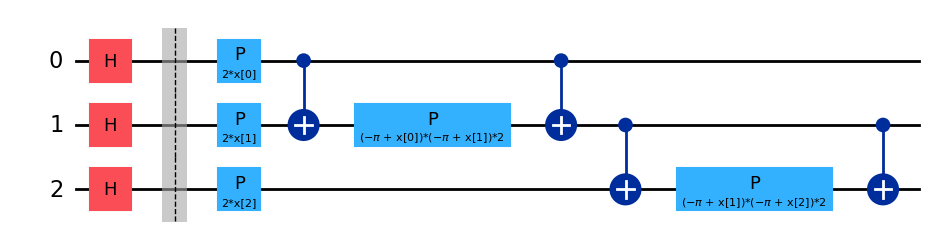

In [51]:
pfm_zz = pauli_feature_map(
    feature_dimension=3,
    entanglement="linear",
    reps=1,
    paulis=["Z", "ZZ"],
    insert_barriers=True,
)
print("PFM with paulis=['Z','ZZ'] is equivalent to ZZFeatureMap:")
pfm_zz.draw("mpl", fold=-1)

### 8.4 EfficientSU2

A hardware-efficient ansatz that alternates single-qubit rotation layers ($R_Y$, $R_Z$) with entangling layers (CX). Commonly used as a variational form, but can also serve as a dense feature map.

For 2 qubits with 1 repetition, it encodes **12 parameters** — far more features per qubit than simple encodings.

Parameters: 8, Qubits: 2


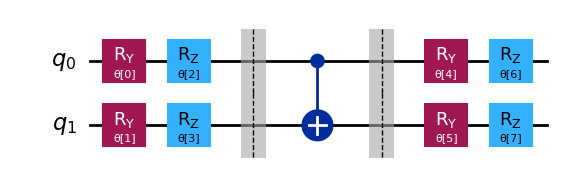

In [52]:
esu2 = efficient_su2(num_qubits=2, reps=1, insert_barriers=True)
print(f"Parameters: {esu2.num_parameters}, Qubits: {esu2.num_qubits}")
esu2.draw("mpl", fold=-1)

3 qubits, 2 reps → 18 parameters


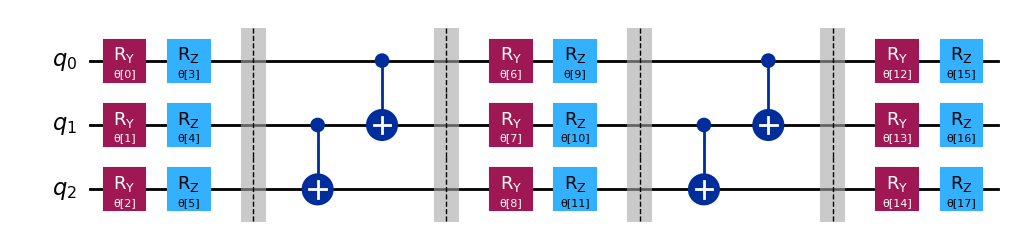

In [53]:
esu2_3q = efficient_su2(num_qubits=3, reps=2, insert_barriers=True)
print(f"3 qubits, 2 reps → {esu2_3q.num_parameters} parameters")
esu2_3q.draw("mpl", fold=-1)

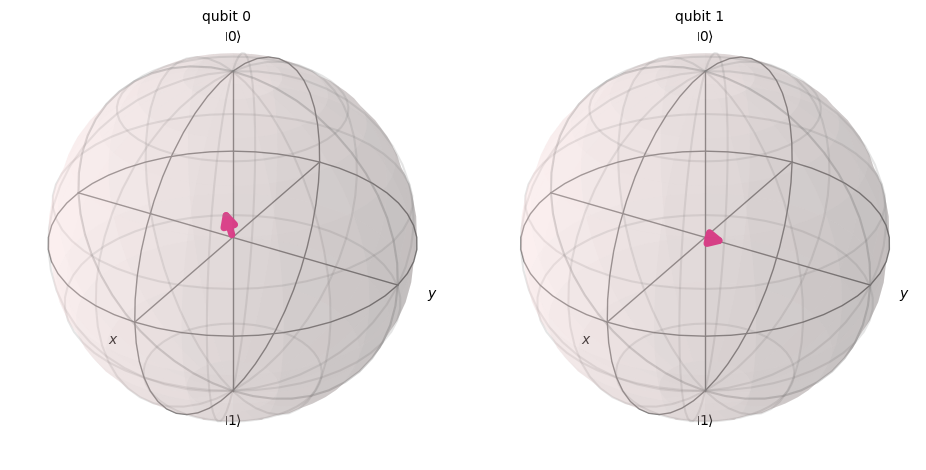

In [54]:
x_esu2 = np.random.uniform(0, 2 * np.pi, esu2.num_parameters)
esu2_bound = esu2.assign_parameters(x_esu2)

sv_esu2 = Statevector.from_instruction(esu2_bound)
plot_bloch_multivector(sv_esu2)

---

## 9. Comparison & Summary

### 9.1 Side-by-Side: All Encodings on the Same Data

Using $\vec{x} = (4, 8, 5, 9)$, let's compare the probability distributions produced by each encoding method.

In [55]:
x_raw = np.array([4, 8, 5, 9], dtype=float)
x_scaled = x_raw * 2 * np.pi / np.max(x_raw)

circuits = {}

# Basis encoding (encode integer 5 on 4 qubits — little-endian)
qc_b = QuantumCircuit(4)
for k in range(4):
    if (5 >> k) & 1:
        qc_b.x(k)
circuits["Basis\n(x=5)"] = qc_b

# Amplitude
qc_a = QuantumCircuit(2)
qc_a.initialize(x_raw / np.linalg.norm(x_raw))
circuits["Amplitude"] = qc_a

# Angle
qc_ang = QuantumCircuit(4)
for k in range(4):
    qc_ang.ry(x_scaled[k], k)
circuits["Angle"] = qc_ang

# Phase
qc_ph = QuantumCircuit(4)
for k in range(4):
    qc_ph.h(k)
    qc_ph.p(x_scaled[k], k)
circuits["Phase"] = qc_ph

# Dense Angle
qc_da = QuantumCircuit(2)
qc_da.ry(x_scaled[0], 0)
qc_da.rz(x_scaled[1], 0)
qc_da.ry(x_scaled[2], 1)
qc_da.rz(x_scaled[3], 1)
circuits["Dense\nAngle"] = qc_da

# ZZ Feature Map
zzfm_cmp = zz_feature_map(feature_dimension=4, entanglement="linear", reps=1)
circuits["ZZ\nFeatureMap"] = zzfm_cmp.assign_parameters(x_scaled.tolist())

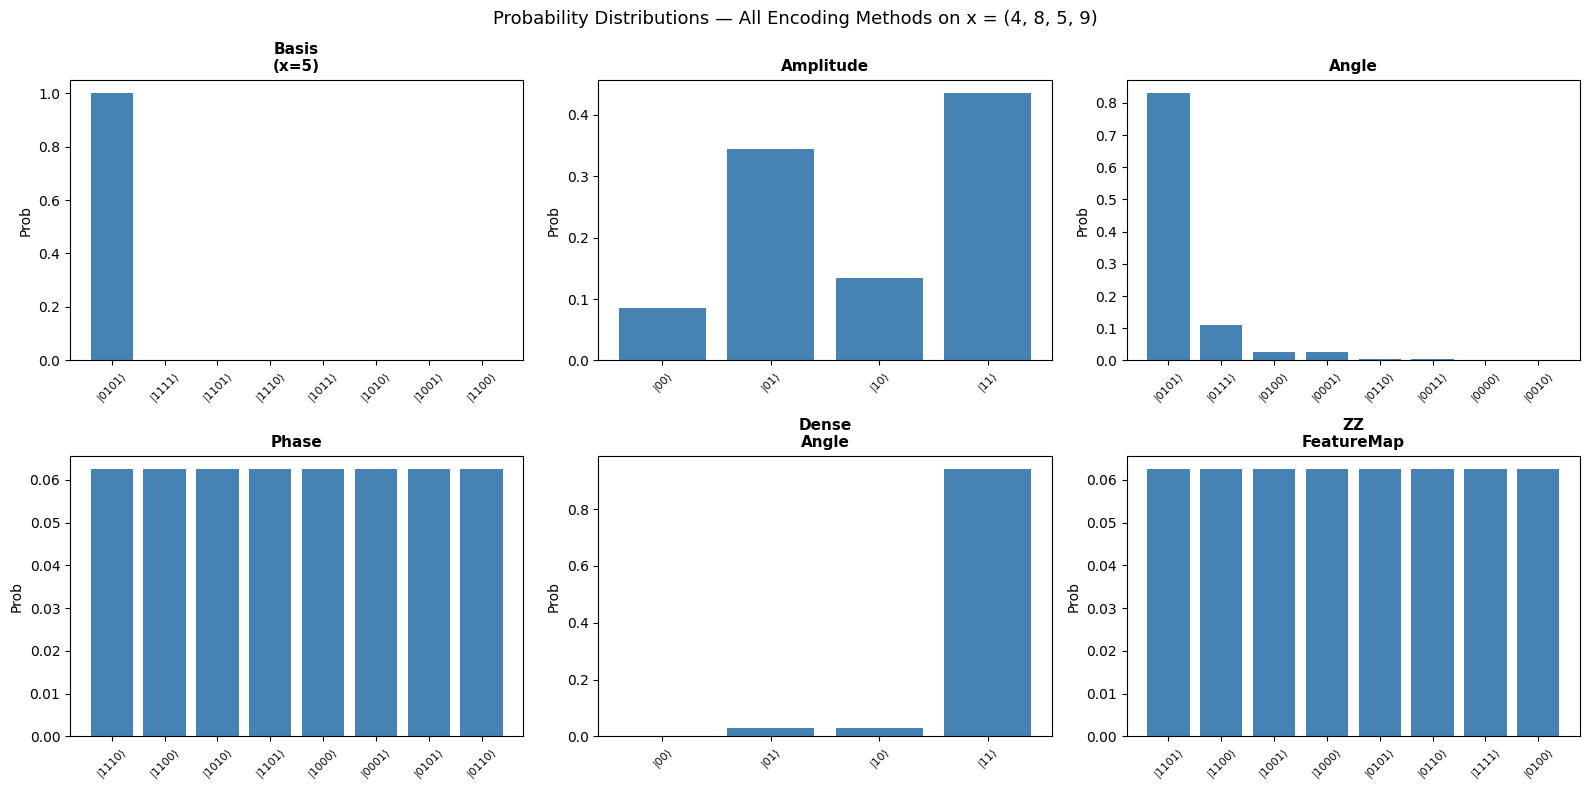

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, (name, qc) in zip(axes, circuits.items()):
    sv = Statevector.from_instruction(qc)
    probs = sv.probabilities()
    n = qc.num_qubits
    labels = [f"|{format(i, f'0{n}b')}⟩" for i in range(2**n)]

    if len(labels) > 8:
        top_idx = np.argsort(probs)[-8:][::-1]
        ax.bar([labels[i] for i in top_idx], probs[top_idx], color="steelblue")
    else:
        ax.bar(labels, probs, color="steelblue")

    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_ylabel("Prob")
    ax.tick_params(axis="x", rotation=45, labelsize=8)

plt.suptitle("Probability Distributions — All Encoding Methods on x = (4, 8, 5, 9)", fontsize=13)
plt.tight_layout()
plt.show()

### 9.2 Summary Table

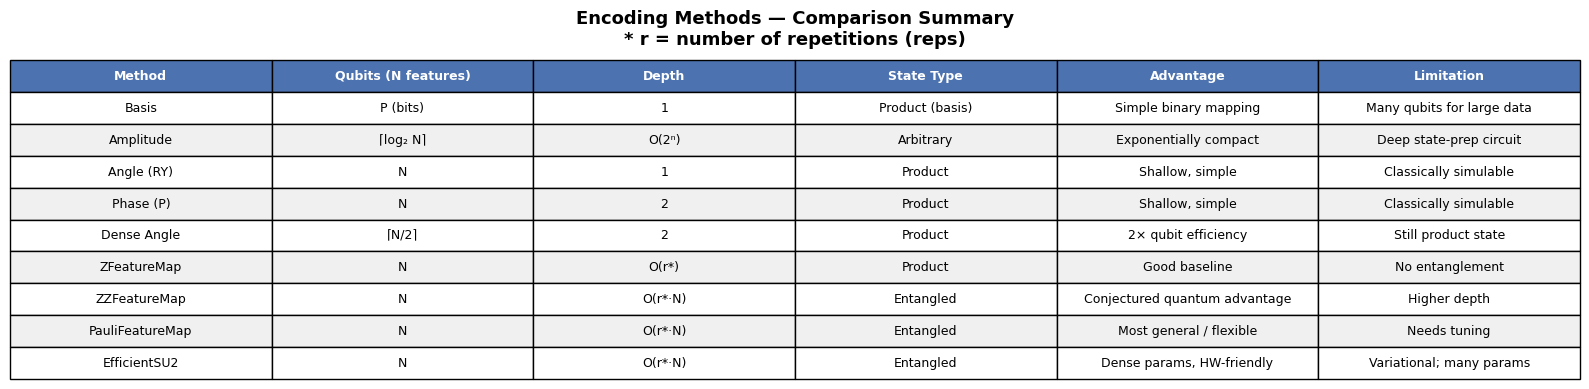

In [61]:
summary = [
    ["Basis",           "P (bits)",           "1",           "Product (basis)",    "Simple binary mapping",           "Many qubits for large data"],
    ["Amplitude",       "⌈log₂ N⌉",          "O(2ⁿ)",      "Arbitrary",          "Exponentially compact",           "Deep state-prep circuit"],
    ["Angle (RY)",      "N",                  "1",           "Product",            "Shallow, simple",                 "Classically simulable"],
    ["Phase (P)",       "N",                  "2",           "Product",            "Shallow, simple",                 "Classically simulable"],
    ["Dense Angle",     "⌈N/2⌉",             "2",           "Product",            "2× qubit efficiency",            "Still product state"],
    ["ZFeatureMap",     "N",                  "O(r*)",       "Product",            "Good baseline",                   "No entanglement"],
    ["ZZFeatureMap",    "N",                  "O(r*·N)",     "Entangled",          "Conjectured quantum advantage",   "Higher depth"],
    ["PauliFeatureMap", "N",                  "O(r*·N)",     "Entangled",          "Most general / flexible",         "Needs tuning"],
    ["EfficientSU2",    "N",                  "O(r*·N)",     "Entangled",          "Dense params, HW-friendly",       "Variational; many params"],
]

columns = ["Method", "Qubits (N features)", "Depth", "State Type", "Advantage", "Limitation"]

fig, ax = plt.subplots(figsize=(16, 4))
ax.axis("off")

table = ax.table(
    cellText=summary,
    colLabels=columns,
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 2)

for j in range(len(columns)):
    table[0, j].set_facecolor("#4C72B0")
    table[0, j].set_text_props(color="white", fontweight="bold")

for i in range(1, len(summary) + 1):
    color = "#f0f0f0" if i % 2 == 0 else "white"
    for j in range(len(columns)):
        table[i, j].set_facecolor(color)

plt.title("Encoding Methods — Comparison Summary\n* r = number of repetitions (reps)", fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

### 9.3 Qubit Scaling Comparison

---

## Key Takeaways

1. **No free lunch** — qubit-efficient methods (amplitude) pay with circuit depth; shallow methods (angle, phase) pay with qubit count.

2. **Entanglement matters** — product-state encodings (angle, phase, ZFM) are classically simulable. Feature maps with entanglement (ZZFM, PFM) are conjectured necessary for quantum advantage.

3. **Data reuploading** — encoding features before *and after* entanglement layers (multiple reps) increases expressivity.

4. **Hardware constraints** — real devices have limited connectivity and native gate sets. `EfficientSU2` is designed to be hardware-friendly. Always check transpiled circuit depth before running on a backend.

### Expressibility vs. Trainability

Two key properties govern the practical usefulness of a feature map:

- **Expressibility** — how much of the Hilbert space the parameterized circuit can reach. Highly expressive circuits (many parameters, entanglement, more reps) can represent a richer set of quantum states, which is needed for complex decision boundaries.

- **Trainability** — how easy it is for a classical optimizer to find good parameter values. Highly expressive circuits with deep entangling layers are prone to **barren plateaus** — regions where the cost function gradient vanishes exponentially with qubit count, making optimization intractable.

The practical challenge is balancing these two:

| | Low Expressibility | High Expressibility |
|---|---|---|
| **Easy to train** | Angle/Phase encoding — trainable but limited decision boundaries | Sweet spot (if it exists) |
| **Hard to train** | — | Deep circuits with many reps — barren plateaus |


---

## References

- IBM Quantum Learning — [Data Encoding](https://quantum.cloud.ibm.com/learning/en/courses/quantum-machine-learning/data-encoding) (Quantum Machine Learning course)

---

## Disclosure

- **Qiskit version:** 2.x
- **AI-assisted:** Claude Code (Opus 4.6)